<a href="https://colab.research.google.com/github/seungah-lab/Intelligence-powered-epidemiology/blob/main/Week_10_ADNEX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ADNEX-based Machine Learning Models for Ovarian Cancer Risk Prediction among Women Admitted for Surgery
================================================================
Implements the machine learning methodology described in the ADNEX model paper:
  Van Calster B et al. "Evaluating the risk of ovarian cancer before surgery
  using the ADNEX model to differentiate between benign, borderline, early and
  advanced stage invasive, and secondary metastatic tumours"
  BMJ 2014; 349: g5920

Dataset: createOvdata (data_case_study.txt)
  TransIOTA study – clinical, ultrasound and biomarker data of patients with
  adnexal masses who underwent surgery.

ADNEX model uses 9 predictors:
  Clinical  : age, serum CA-125 (log), type of centre (oncology vs other)
  Ultrasound: max lesion diameter, proportion solid tissue, >10 cyst locules,
              number of papillary projections, acoustic shadows, ascites

Outcome: binary benign (0) vs malignant (1)
  pmalwo: pre-computed ADNEX probability (used as benchmark)

In [13]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, cross_val_predict, cross_validate
)
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV


### 1. Load data
##### Updated path to the specific location

In [16]:
import pandas as pd

# 1. Define the raw GitHub URL
adnmass = "https://raw.githubusercontent.com/seungah-lab/Intelligence-powered-epidemiology/940efc0ee46a48ded32a54a9e93913fe67078d09/Week%2010/TransIOTA_identification%20of%20new%20potential%20biomarkers%20for%20the%20Dx%20of%20Ov%20cancer/TransIOTA.csv"

# 2. Load data
df = pd.read_csv(adnmass)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

print(f"\nOutcome distribution:")
if "Outcome1" in df.columns:
    display(df["Outcome1"].value_counts())
else:
    print("Column 'Outcome1' not found. Available columns are:", df.columns.tolist())

missing = df.isnull().sum()
if missing.any():
    print(f"\nMissing values:\n{missing[missing > 0]}")
else:
    print("\nNo missing values found.")

Dataset shape: (997, 15)
Columns: ['patient_ID', 'Outcome1', 'Histologic_Diagnosis', 'pmalwo', 'RMI', 'Age', 'Postmenopausal', 'Oncology_Center', 'Serum_CA125', 'Maximal_Diameter_Lesion', 'Proportion_Solid_Tissue', 'More_Than_10_Cyst_Locules', 'No_of_Papillary_Projections', 'Acoustic_Shadows', 'Ascites']

Outcome distribution:


,count
Outcome1,
0,742
1,255



No missing values found.


### 2. Feature Engineering (ADNEX predictors)

In [17]:
# log-transform CA-125 (base-10 log of Serum_CA125+1 to handle 0s)
df["log_CA125"] = np.log10(df["Serum_CA125"] + 1)

# Papillary projections: original ADNEX used 5 categories (0,1,2,3,≥4)
# In this dataset, the column is 'No_of_Papillary_Projections'
df["papnr_cat"] = df["No_of_Papillary_Projections"].clip(upper=4).astype(int)
pap_dummies = pd.get_dummies(df["papnr_cat"], prefix="pap", drop_first=False)
pap_dummies = pap_dummies.add_prefix("").rename(columns={
    "pap_0": "pap_0", "pap_1": "pap_1", "pap_2": "pap_2",
    "pap_3": "pap_3", "pap_4": "pap_ge4"
})
# Drop reference category (pap_0) for model matrix
pap_model = pap_dummies.drop(columns=["pap_0"])

# ADNEX 9-predictor feature matrix mapped to TransIOTA.csv columns
ADNEX_FEATURES = [
    "Age",                      # 1. Age
    "log_CA125",                # 2. log(CA-125)
    "Oncology_Center",          # 3. Type of centre (oncology=1)
    "Maximal_Diameter_Lesion",  # 4. Max lesion diameter (mm)
    "Proportion_Solid_Tissue",  # 5. Proportion solid tissue
    "More_Than_10_Cyst_Locules", # 6. >10 cyst locules (binary)
    "Acoustic_Shadows",         # 7. Acoustic shadows (binary)
    "Ascites",                  # 8. Ascites (binary)
]

# Combine base features + papillary projection dummies (replaces papnr)
X_adnex = pd.concat([df[ADNEX_FEATURES], pap_model], axis=1)
y = df["Outcome1"].astype(int)   # 0=Benign, 1=Malignant

print(f"\nADNEX feature matrix shape: {X_adnex.shape}")
print(f"Features: {list(X_adnex.columns)}")
print(f"\nPrevalence of malignancy: {y.mean():.1%}")

# Pre-computed ADNEX predictions from the original model (benchmark)
p_adnex_original = df["pmalwo"].values


ADNEX feature matrix shape: (997, 12)
Features: ['Age', 'log_CA125', 'Oncology_Center', 'Maximal_Diameter_Lesion', 'Proportion_Solid_Tissue', 'More_Than_10_Cyst_Locules', 'Acoustic_Shadows', 'Ascites', 'pap_1', 'pap_2', 'pap_3', 'pap_ge4']

Prevalence of malignancy: 25.6%


### 3. Model Definitions - 전체의 25.6%가 악성 난소암이므로 엄청 고위험 집단임

In [20]:
# All models wrapped in pipelines that scale continuous features - data leackage를 막기 위해 미리 training set에서만 연속 변수를 정규화
MODELS = {
    "ADNEX (original)": None,  # pre-computed; evaluated separately
    "Logistic Regression\n(ADNEX predictors)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs", max_iter=1000, C=1.0, random_state=42
        )),
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=500, max_depth=5, min_samples_leaf=10,
            random_state=42
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            min_samples_leaf=10, random_state=42
        )),
    ]),
    "SVM (calibrated)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", CalibratedClassifierCV(
            SVC(kernel="rbf", C=1.0, gamma="scale", probability=False),
            method="sigmoid", cv=5
        )),
    ]),
    "k-NN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=15, weights="distance")),
    ]),
}


### 4. Cross-validated predictions (10-fold stratified CV)

In [21]:
CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_probs = {}  # model_name -> predicted probability array

print("\nRunning 10-fold cross-validation …")
for name, pipe in MODELS.items():
    if pipe is None:
        cv_probs[name] = p_adnex_original
    else:
        proba = cross_val_predict(
            pipe, X_adnex, y, cv=CV, method="predict_proba"
        )[:, 1]
        cv_probs[name] = proba
        print(f"  {name.split(chr(10))[0]}: done")


Running 10-fold cross-validation …
  Logistic Regression: done
  Random Forest: done
  Gradient Boosting: done
  SVM (calibrated): done
  k-NN: done


### 5. Performance Metrics

In [23]:
THRESHOLD = 0.10   # 10 % risk threshold (recommended in ADNEX paper)

def performance_metrics(y_true, y_prob, threshold=THRESHOLD):
    """Return a dict of key performance measures."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens  = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spec  = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    ppv   = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    npv   = tn / (tn + fn) if (tn + fn) > 0 else np.nan
    return {
        "AUC-ROC"     : roc_auc_score(y_true, y_prob),
        "AUC-PRC"     : average_precision_score(y_true, y_prob),
        "Brier Score" : brier_score_loss(y_true, y_prob),
        "Sensitivity" : sens,
        "Specificity" : spec,
        "PPV"         : ppv,
        "NPV"         : npv,
    }

rows = []
for name, proba in cv_probs.items():
    m = performance_metrics(y, proba)
    m["Model"] = name.replace("\n", " ")
    rows.append(m)

results_df = pd.DataFrame(rows).set_index("Model")
print("\n" + "="*70)
print("Performance metrics (10-fold CV, threshold = 10%)")
print("="*70)
print(results_df.to_string(float_format=lambda x: f"{x:.3f}"))


Performance metrics (10-fold CV, threshold = 10%)
                                        AUC-ROC  AUC-PRC  Brier Score  Sensitivity  Specificity   PPV   NPV
Model                                                                                                      
ADNEX (original)                          0.953    0.890        0.110        1.000        0.147 0.287 1.000
Logistic Regression (ADNEX predictors)    0.998    0.995        0.014        0.988        0.962 0.900 0.996
Random Forest                             0.996    0.990        0.027        0.996        0.822 0.658 0.998
Gradient Boosting                         0.998    0.993        0.017        0.984        0.965 0.906 0.994
SVM (calibrated)                          0.998    0.994        0.015        0.984        0.939 0.848 0.994
k-NN                                      0.988    0.979        0.026        0.980        0.925 0.817 0.993


### 6. Visualisation

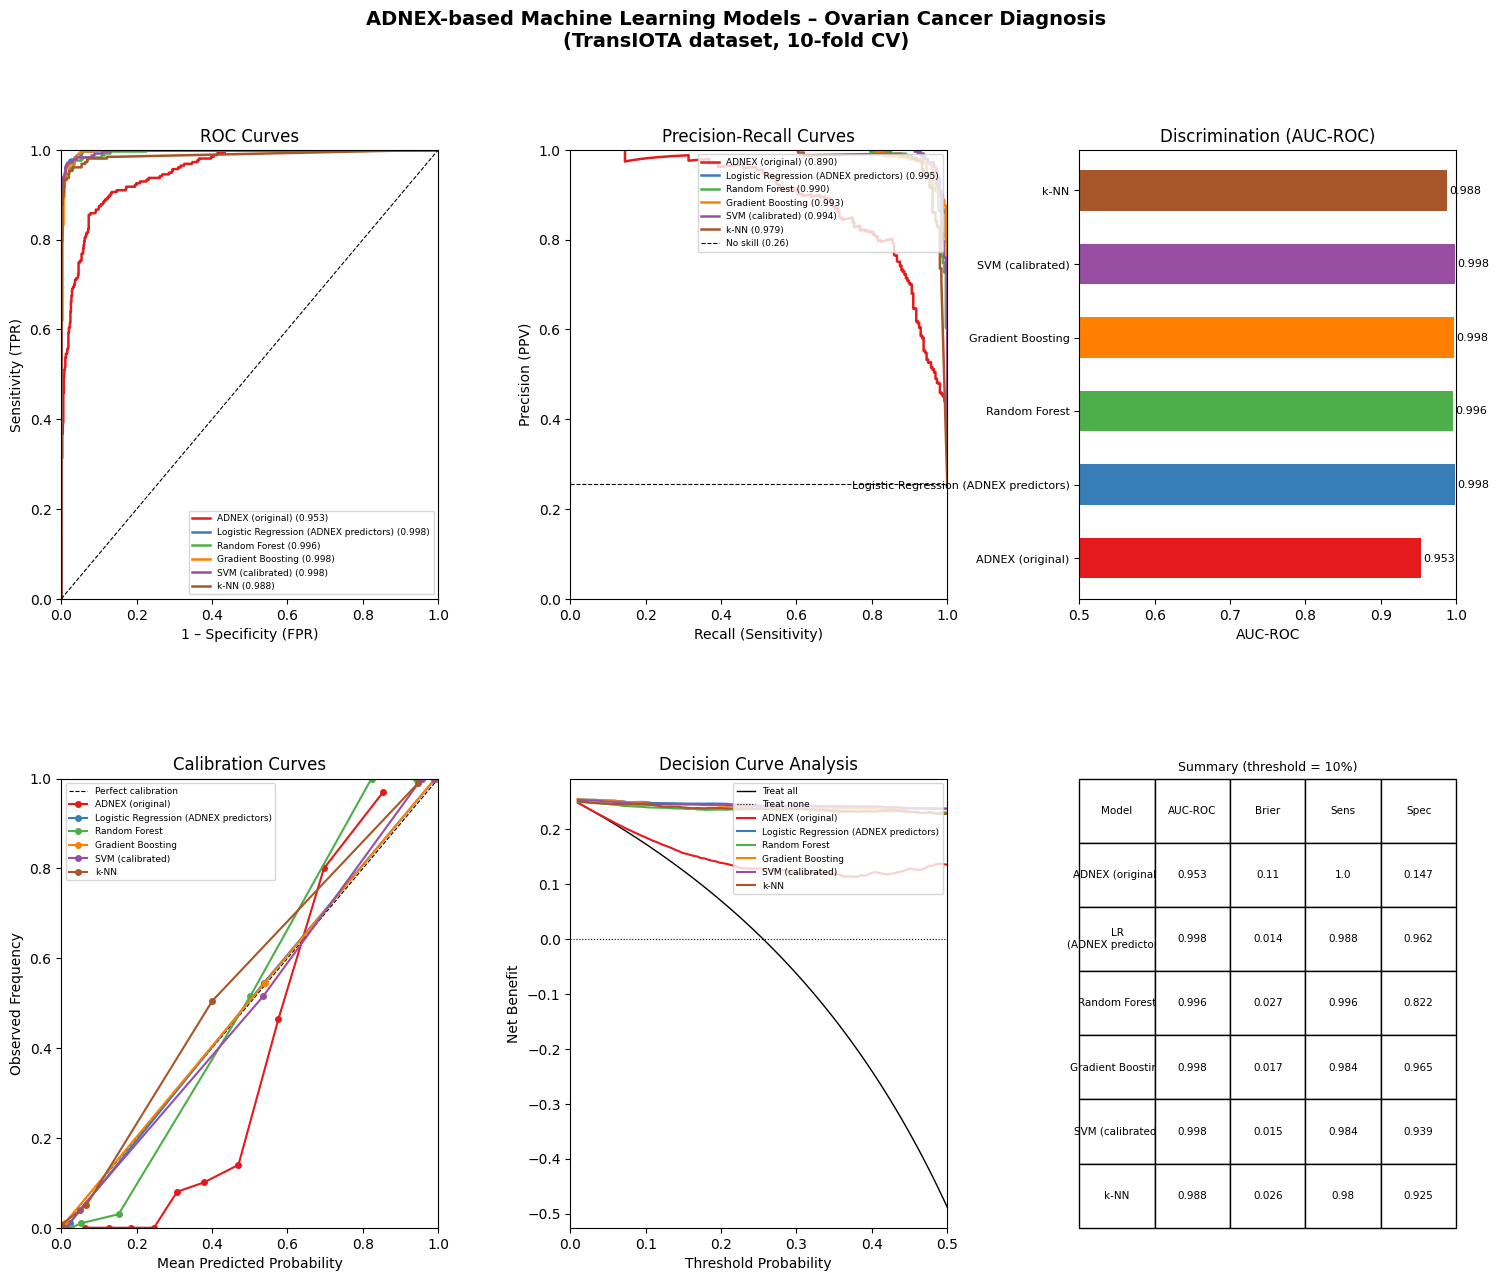


Figure generated for TransIOTA dataset.


In [34]:
COLORS = {
    "ADNEX (original)"              : "#e41a1c",
    "Logistic Regression (ADNEX predictors)": "#377eb8",
    "Random Forest"                 : "#4daf4a",
    "Gradient Boosting"             : "#ff7f00",
    "SVM (calibrated)"              : "#984ea3",
    "k-NN"                          : "#a65628",
}

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "ADNEX-based Machine Learning Models – Ovarian Cancer Diagnosis\n"
    "(TransIOTA dataset, 10-fold CV)",
    fontsize=14, fontweight="bold", y=0.98
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

# 6a. ROC curves ────────────────────────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[0, 0])
for name, proba in cv_probs.items():
    label = name.replace("\n", " ")
    auc = roc_auc_score(y, proba)
    fpr, tpr, _ = roc_curve(y, proba)
    ax_roc.plot(fpr, tpr, label=f"{label} ({auc:.3f})",
                color=COLORS.get(label, "gray"), lw=1.8)
ax_roc.plot([0, 1], [0, 1], "k--", lw=0.8)
ax_roc.set_xlabel("1 – Specificity (FPR)")
ax_roc.set_ylabel("Sensitivity (TPR)")
ax_roc.set_title("ROC Curves")
ax_roc.legend(fontsize=6.5, loc="lower right")
ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1)

# 6b. Precision-Recall curves ─────────────────────────────────────────────────────────────────
ax_prc = fig.add_subplot(gs[0, 1])
baseline_pr = y.mean()
for name, proba in cv_probs.items():
    label = name.replace("\n", " ")
    ap = average_precision_score(y, proba)
    prec, rec, _ = precision_recall_curve(y, proba)
    ax_prc.plot(rec, prec, label=f"{label} ({ap:.3f})",
                color=COLORS.get(label, "gray"), lw=1.8)
ax_prc.axhline(baseline_pr, color="k", ls="--", lw=0.8,
               label=f"No skill ({baseline_pr:.2f})")
ax_prc.set_xlabel("Recall (Sensitivity)")
ax_prc.set_ylabel("Precision (PPV)")
ax_prc.set_title("Precision-Recall Curves")
ax_prc.legend(fontsize=6.5, loc="upper right")
ax_prc.set_xlim(0, 1); ax_prc.set_ylim(0, 1)

# 6c. AUC-ROC bar chart ──────────────────────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[0, 2])
labels_bar = [n.replace("\n", " ") for n in cv_probs.keys()]
aucs = [roc_auc_score(y, p) for p in cv_probs.values()]
colors_bar = [COLORS.get(n.replace("\n", " "), "gray") for n in cv_probs.keys()]
bars = ax_bar.barh(range(len(labels_bar)), aucs, color=colors_bar, height=0.55)
ax_bar.set_yticks(range(len(labels_bar)))
ax_bar.set_yticklabels(labels_bar, fontsize=8)
ax_bar.set_xlabel("AUC-ROC")
ax_bar.set_title("Discrimination (AUC-ROC)")
ax_bar.set_xlim(0.5, 1.0)
for bar, auc in zip(bars, aucs):
    ax_bar.text(auc + 0.003, bar.get_y() + bar.get_height() / 2,
                f"{auc:.3f}", va="center", fontsize=8)

# 6d. Calibration curves ───────────────────────────────────────────────────────────
ax_cal = fig.add_subplot(gs[1, 0])
ax_cal.plot([0, 1], [0, 1], "k--", lw=0.8, label="Perfect calibration")
for name, proba in cv_probs.items():
    label = name.replace("\n", " ")
    prob_true, prob_pred = calibration_curve(y, proba, n_bins=10,
                                             strategy="quantile")
    ax_cal.plot(prob_pred, prob_true, "o-", label=label,
                color=COLORS.get(label, "gray"), lw=1.5, ms=4)
ax_cal.set_xlabel("Mean Predicted Probability")
ax_cal.set_ylabel("Observed Frequency")
ax_cal.set_title("Calibration Curves")
ax_cal.legend(fontsize=6.5, loc="upper left")
ax_cal.set_xlim(0, 1); ax_cal.set_ylim(0, 1)

# 6e. Decision Curve Analysis (simplified net benefit) ───────────────────────
ax_dca = fig.add_subplot(gs[1, 1])
thresholds = np.linspace(0.01, 0.50, 100)
n = len(y)

def net_benefit(y_true, y_prob, thresholds):
    nb = []
    for t in thresholds:
        tp = np.sum((y_prob >= t) & (y_true == 1))
        fp = np.sum((y_prob >= t) & (y_true == 0))
        nb.append((tp / n) - (fp / n) * (t / (1 - t)))
    return np.array(nb)

# \"Treat all\" net benefit
nb_all = [(y.sum() / n) - ((n - y.sum()) / n) * (t / (1 - t))
          for t in thresholds]

ax_dca.plot(thresholds, nb_all, "k-", lw=1, label="Treat all")
ax_dca.axhline(0, color="k", ls=":", lw=0.8, label="Treat none")
for name, proba in cv_probs.items():
    label = name.replace("\n", " ")
    nb = net_benefit(y.values, proba, thresholds)
    ax_dca.plot(thresholds, nb, label=label,
                color=COLORS.get(label, "gray"), lw=1.5)
ax_dca.set_xlabel("Threshold Probability")
ax_dca.set_ylabel("Net Benefit")
ax_dca.set_title("Decision Curve Analysis")
ax_dca.legend(fontsize=6.5, loc="upper right")
ax_dca.set_xlim(0, 0.5)

# 6f. Brier score & sensitivity/specificity summary table ─────────────────────
ax_tbl = fig.add_subplot(gs[1, 2])
ax_tbl.axis("off")
tbl_data = results_df[
    ["AUC-ROC", "Brier Score", "Sensitivity", "Specificity"]
].reset_index()
tbl_data.columns = ["Model", "AUC-ROC", "Brier", "Sens", "Spec"]
tbl_data["Model"] = tbl_data["Model"].str.replace(
    "Logistic Regression ", "LR\n"
).str.replace(" (ADNEX predictors)", "", regex=False)
cell_text = tbl_data.values.tolist()
col_labels = list(tbl_data.columns)
tbl = ax_tbl.table(
    cellText=[[str(round(v, 3)) if isinstance(v, float) else v
               for v in row] for row in cell_text],
    colLabels=col_labels,
    cellLoc="center", loc="center", bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
ax_tbl.set_title(f"Summary (threshold = {THRESHOLD:.0%})", fontsize=9)

plt.show()
print("\nFigure generated for TransIOTA dataset.")

### 7. Logistic Regression coefficients

In [35]:
lr_pipe = MODELS["Logistic Regression\n(ADNEX predictors)"]
lr_pipe.fit(X_adnex, y)
lr_clf = lr_pipe.named_steps["clf"]
feature_names = list(X_adnex.columns)
coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": lr_clf.coef_[0], "Odds Ratio": np.exp(lr_clf.coef_[0])})
print("\n" + "="*50)
print("Logistic Regression (ADNEX predictors) – Coefficients")
print("="*50)
print(coef_df.sort_values("Coefficient", ascending=False).to_string(index=False, float_format=lambda x: f"{x:.4f}"))



Logistic Regression (ADNEX predictors) – Coefficients
                  Feature  Coefficient  Odds Ratio
  Proportion_Solid_Tissue       3.1869     24.2137
                log_CA125       1.4814      4.3989
  Maximal_Diameter_Lesion       1.2776      3.5879
                  Ascites       1.1101      3.0346
                    pap_3       0.9511      2.5885
                  pap_ge4       0.6826      1.9791
                    pap_2       0.5424      1.7201
                    pap_1       0.4949      1.6404
More_Than_10_Cyst_Locules       0.1185      1.1258
          Oncology_Center      -0.0804      0.9227
                      Age      -0.3177      0.7278
         Acoustic_Shadows      -1.1179      0.3270


### 8. Feature importance (Random Forest)

In [36]:
rf_pipe = MODELS["Random Forest"]
rf_pipe.fit(X_adnex, y)
rf_clf = rf_pipe.named_steps["clf"]
imp_df = pd.DataFrame({"Feature": feature_names, "Importance": rf_clf.feature_importances_})
print("\n" + "="*50)
print("Random Forest – Feature Importances")
print("="*50)
print(imp_df.sort_values("Importance", ascending=False).to_string(index=False, float_format=lambda x: f"{x:.4f}"))



Random Forest – Feature Importances
                  Feature  Importance
  Proportion_Solid_Tissue      0.4782
                log_CA125      0.1920
                  Ascites      0.1562
  Maximal_Diameter_Lesion      0.1136
                  pap_ge4      0.0177
                    pap_3      0.0149
         Acoustic_Shadows      0.0110
                    pap_2      0.0061
                      Age      0.0042
More_Than_10_Cyst_Locules      0.0038
                    pap_1      0.0013
          Oncology_Center      0.0009


### 9. Final comparison

In [38]:
print("\n" + "="*60)
print("External ADNEX benchmark vs re-fit Logistic Regression")
print("="*60)
lr_cv_probs = cv_probs["Logistic Regression\n(ADNEX predictors)"]
print(f"  ADNEX original  AUC: {roc_auc_score(y, p_adnex_original):.3f}  Brier: {brier_score_loss(y, p_adnex_original):.3f}")
print(f"  Logistic Reg    AUC: {roc_auc_score(y, lr_cv_probs):.3f}  Brier: {brier_score_loss(y, lr_cv_probs):.3f}")


External ADNEX benchmark vs re-fit Logistic Regression
  ADNEX original  AUC: 0.953  Brier: 0.110
  Logistic Reg    AUC: 0.998  Brier: 0.014
